<a href="https://colab.research.google.com/github/Anoushehm/intro-ml-course-winter2026/blob/main/Edited_HAD5016_Datathon_4_202602_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HAD5016 - Datathon #4
**Project:** This colab file aims to answer to the following questions:
Can we classify Activity (0–12) using the wearable sensor signals?

1.   How well can these signals separate sedentary postures (lying/sitting/standing) from locomotion (walking/jogging/running/stairs) and repetitive exertion tasks (bends, arm elevation, knee bends, jumping)?
2.   Does a sequence model (LSTM) work better than a simple baseline neural network (MLP) for this time-series task?


 **Data:** Datathon #4 – mHealth Dataset (CSV)


**Programmer:** Anousheh Marouzi, Ubah Ahmed, Zhenxiao Yang

**Team Number:** 4


**Date started:** March 7th, 2026

**Last update:** March 11th, 2026


# 0. Setup


In [ ]:
# Install required libraries
!pip install numpy pandas scikit-learn matplotlib seaborn tensorflow

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Flatten
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load Dataset and Explore


In [ ]:
from google.colab import files
uploaded = files.upload()

# Load dataset
mhealth_RAW = pd.read_csv(list(uploaded.keys())[0])

# View the first few rows of the dataset
mhealth_RAW.head()

Saving Datathon #4 - mhealth Dataset - HAD7001 (1).csv to Datathon #4 - mhealth Dataset - HAD7001 (1) (1).csv


,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,0,subject1


In [ ]:
df = mhealth_RAW.copy()

In [ ]:
# Count the number of rows and columns in the dataset
print("Dataset shape:", mhealth_RAW.shape)

# Print variable names
print("\nColumns:")
print(mhealth_RAW.columns)

# Search for missing values
print("\nMissing values:")
print(mhealth_RAW.isna().sum())

# Print values captured in the subject variable
print("\nSubjects:")
print(mhealth_RAW['subject'].unique())

# Ch

Dataset shape: (999999, 14)

Columns:
Index(['alx', 'aly', 'alz', 'glx', 'gly', 'glz', 'arx', 'ary', 'arz', 'grx',
       'gry', 'grz', 'Activity', 'subject'],
      dtype='object')

Missing values:
alx         0
aly         0
alz         0
glx         0
gly         0
glz         0
arx         0
ary         0
arz         0
grx         0
gry         0
grz         0
Activity    0
subject     0
dtype: int64

Subjects:
['subject1' 'subject2' 'subject3' 'subject4' 'subject5' 'subject6'
 'subject7' 'subject8' 'subject9']


In [ ]:
# Define sensor feautres
sensor_features = [c for c in df.columns if c not in ['Activity','Category','subject']]

X = df[sensor_features]
y_activity = df['Activity']
subjects = df['subject']

In [ ]:
# Map activities to the 3 categories

def map_activity_category(activity):

    sedentary = [1,2,3]
    locomotion = [4,5,6,7,8]
    exertion = [9,10,11,12]

    if activity in sedentary:
        return 0   # Sedentary
    elif activity in locomotion:
        return 1   # Locomotion
    elif activity in exertion:
        return 2   # Exertion
    else:
        return -1  # remove null activity


df["Category"] = df["Activity"].apply(map_activity_category)

# Remove rows with null activity
df = df[df["Category"] != -1]

3. Confirm Columns and Basic Cleaning

Your proposal states 12 sensor features + activity + subject.

In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns)

# Check missing values
missing = df.isna().sum()
print(missing)

# Drop rows with missing values (if any)
df = df.dropna()

# Confirm subjects
print("Unique subjects:", df['subject'].unique())

Shape: (279053, 15)
Columns: Index(['alx', 'aly', 'alz', 'glx', 'gly', 'glz', 'arx', 'ary', 'arz', 'grx',
       'gry', 'grz', 'Activity', 'subject', 'Category'],
      dtype='object')
alx         0
aly         0
alz         0
glx         0
gly         0
glz         0
arx         0
ary         0
arz         0
grx         0
gry         0
grz         0
Activity    0
subject     0
Category    0
dtype: int64
Unique subjects: ['subject1' 'subject2' 'subject3' 'subject4' 'subject5' 'subject6'
 'subject7' 'subject8' 'subject9']


4. Define Sensor Features and Labels

In [ ]:
sensor_features = [col for col in df.columns if col not in ['Activity', 'subject']]

X = df[sensor_features].values
y = df['Activity'].values
subjects = df['subject'].values

print("Features:", len(sensor_features))

Features: 13


In [ ]:
print("df shape:", df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("subjects shape:", subjects.shape)
print("unique subjects:", len(np.unique(subjects)))
print("unique activities:", np.unique(y))
print(df[['subject', 'Activity']].head(10))

df shape: (279053, 15)
X shape: (279053, 13)
y shape: (279053,)
subjects shape: (279053,)
unique subjects: 9
unique activities: [ 1  2  3  4  5  6  7  8  9 10 11 12]
       subject  Activity
6656  subject1         1
6657  subject1         1
6658  subject1         1
6659  subject1         1
6660  subject1         1
6661  subject1         1
6662  subject1         1
6663  subject1         1
6664  subject1         1
6665  subject1         1


5. Standardize Sensor Signals

6. Create Rolling Windows (Time Series Sequences)

Your dataset is sampled at 50 Hz.

1 second window = 50 samples

In [ ]:
WINDOW_SIZE = 50
STEP = 25

def create_windows(X, y, subjects, window_size, step):

    X_windows = []
    y_windows = []
    subject_windows = []

    for i in range(0, len(X) - window_size, step):

        window = X[i:i+window_size]
        label = y[i:i+window_size]
        subject = subjects[i:i+window_size]

        if len(set(label)) == 1:
            X_windows.append(window)
            y_windows.append(label[0])
            subject_windows.append(subject[0])

    return np.array(X_windows), np.array(y_windows), np.array(subject_windows)

In [ ]:
X_seq, y_seq, subject_seq = create_windows(X, y, subjects, WINDOW_SIZE, STEP)

In [ ]:
print("subject_seq shape:", subject_seq.shape)
print("unique subjects in subject_seq:", np.unique(subject_seq))
print("number of unique subjects:", len(np.unique(subject_seq)))

subject_seq shape: (10975,)
unique subjects in subject_seq: ['subject1' 'subject2' 'subject3' 'subject4' 'subject5' 'subject6'
 'subject7' 'subject8' 'subject9']
number of unique subjects: 9


7. Train / Validation / Test Split (80/10/10)

To avoid data leakage, split by subjects.

In [ ]:
unique_subjects = np.unique(subject_seq)

train_subj, temp_subj = train_test_split(unique_subjects, test_size=0.2, random_state=42)
val_subj, test_subj = train_test_split(temp_subj, test_size=0.5, random_state=42)

def subject_split(X, y, subjects, subject_list):

    mask = np.isin(subjects, subject_list)

    return X[mask], y[mask]

X_train, y_train = subject_split(X_seq, y_seq, subject_seq, train_subj)
X_val, y_val = subject_split(X_seq, y_seq, subject_seq, val_subj)
X_test, y_test = subject_split(X_seq, y_seq, subject_seq, test_subj)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (8267, 50, 13)
Validation: (1310, 50, 13)
Test: (1398, 50, 13)


In [ ]:
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_val_2d = X_val.reshape(-1, X_val.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

X_train = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val = scaler.transform(X_val_2d).reshape(X_val.shape)
X_test = scaler.transform(X_test_2d).reshape(X_test.shape)

Handle Imbalance

In [ ]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

print("Class weights:", class_weight)

Class weights: {np.int64(1): np.float64(0.8143223010244287), np.int64(2): np.float64(0.9088610378188214), np.int64(3): np.float64(0.9502298850574713), np.int64(4): np.float64(0.9502298850574713), np.int64(5): np.float64(0.9424304605563155), np.int64(6): np.float64(0.9926753121998079), np.int64(7): np.float64(1.0013323643410852), np.int64(8): np.float64(1.0013323643410852), np.int64(9): np.float64(0.948921028466483), np.int64(10): np.float64(0.9515423572744015), np.int64(11): np.float64(0.948921028466483), np.int64(12): np.float64(2.919138418079096)}


8. Baseline Model: MLP

Flatten sequences into vectors.

In [ ]:
X_train_mlp = X_train.reshape(X_train.shape[0], -1)
X_val_mlp = X_val.reshape(X_val.shape[0], -1)
X_test_mlp = X_test.reshape(X_test.shape[0], -1)

num_classes = int(np.max(y_train)) + 1
print("y_train min/max:", np.min(y_train), np.max(y_train))
print("num_classes:", num_classes)

model_mlp = Sequential([

    Dense(256, activation='relu', input_shape=(X_train_mlp.shape[1],)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history_mlp = model_mlp.fit(
    X_train_mlp, y_train,
    validation_data=(X_val_mlp, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    class_weight=class_weight
)

y_train min/max: 1 12
num_classes: 13
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5865 - loss: 1.3179 - val_accuracy: 0.6710 - val_loss: 1.2516
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9012 - loss: 0.2760 - val_accuracy: 0.7076 - val_loss: 1.0141
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9412 - loss: 0.1629 - val_accuracy: 0.6916 - val_loss: 1.1973
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9594 - loss: 0.1074 - val_accuracy: 0.6992 - val_loss: 1.3698
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9739 - loss: 0.0785 - val_accuracy: 0.7260 - val_loss: 1.4602
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9784 - loss: 0.0638 - val_accuracy: 0.7168 - val_loss: 1.8009
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9848 - loss: 0.0465 - val_accuracy: 0.7069 - val_loss: 1.8187


9. Sequence Model: LSTM

In [ ]:
model_lstm = Sequential([

    LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    class_weight=class_weight
)

Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 13s 144ms/step - accuracy: 0.5250 - loss: 1.7483 - val_accuracy: 0.5687 - val_loss: 1.3027
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.8896 - loss: 0.3216 - val_accuracy: 0.6779 - val_loss: 1.4792
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.9336 - loss: 0.2042 - val_accuracy: 0.6809 - val_loss: 1.7927
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.9637 - loss: 0.1173 - val_accuracy: 0.7176 - val_loss: 1.7894
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.9646 - loss: 0.0994 - val_accuracy: 0.7145 - val_loss: 1.9250
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.9828 - loss: 0.0548 - val_accuracy: 0.6908 - val_loss: 1.7416


10. Model Evaluation

In [ ]:
def evaluate_model(model, X_test, y_test):

    preds = model.predict(X_test)
    preds = np.argmax(preds, axis=1)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')

    print("Accuracy:", acc)
    print("Macro F1:", f1)

    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

11. Evaluate MLP

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.82689556509299
Macro F1: 0.7984687981567372
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       121
           2       1.00      1.00      1.00       121
           3       1.00      1.00      1.00       121
           4       0.99      0.99      0.99       121
           5       0.83      0.87      0.85       121
           6       1.00      0.08      0.15       125
           7       0.96      1.00      0.98       131
           8       0.57      1.00      0.73       135
           9       1.00      1.00      1.00       121
          10       0.63      0.18      0.28       121
          11       0.54      0.95      0.69       121
          12       0.97      0.87      0.92        39

    accuracy                           0.83      1398
   macro avg       0.87      0.83      0.80      1398
weighted avg       0.87      0.83      0.79      1398



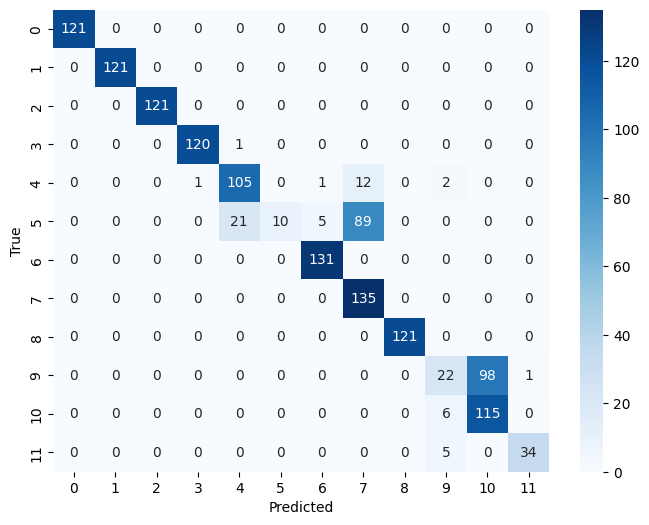

In [ ]:
evaluate_model(model_mlp, X_test_mlp, y_test)

12. Evaluate LSTM

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
Accuracy: 0.7103004291845494
Macro F1: 0.6663613864935157
              precision    recall  f1-score   support

           1       0.98      1.00      0.99       121
           2       0.00      0.00      0.00       121
           3       1.00      1.00      1.00       121
           4       0.86      1.00      0.93       121
           5       0.47      0.82      0.60       121
           6       1.00      0.10      0.18       125
           7       0.94      1.00      0.97       131
           8       0.65      0.61      0.63       135
           9       0.50      1.00      0.67       121
          10       0.77      0.30      0.43       121
          11       0.58      0.96      0.72       121
          12       0.94      0.85      0.89        39

    accuracy                           0.71      1398
   macro avg       0.72      0.72      0.67      1398
weighted avg       0.71      0.71      0.65      1398



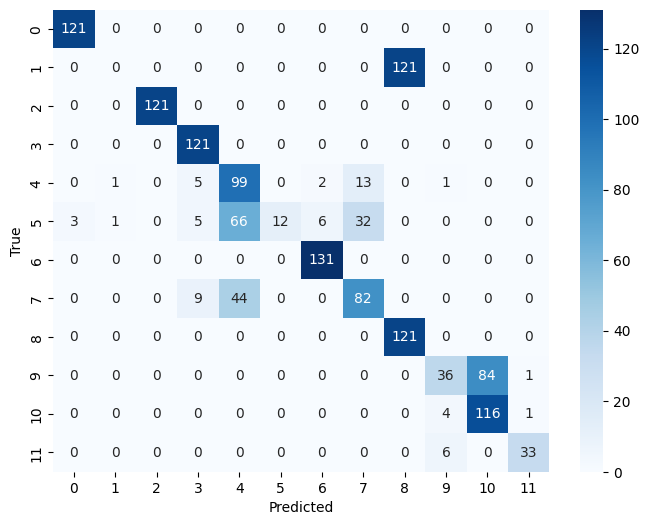

In [ ]:
evaluate_model(model_lstm, X_test, y_test)

13. Compare Models

In [ ]:
mlp_preds = np.argmax(model_mlp.predict(X_test_mlp), axis=1)
lstm_preds = np.argmax(model_lstm.predict(X_test), axis=1)

print("MLP Accuracy:", accuracy_score(y_test, mlp_preds))
print("LSTM Accuracy:", accuracy_score(y_test, lstm_preds))

print("MLP F1:", f1_score(y_test, mlp_preds, average='macro'))
print("LSTM F1:", f1_score(y_test, lstm_preds, average='macro'))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
MLP Accuracy: 0.82689556509299
LSTM Accuracy: 0.7103004291845494
MLP F1: 0.7984687981567372
LSTM F1: 0.6663613864935157


14. Plot Training Curves

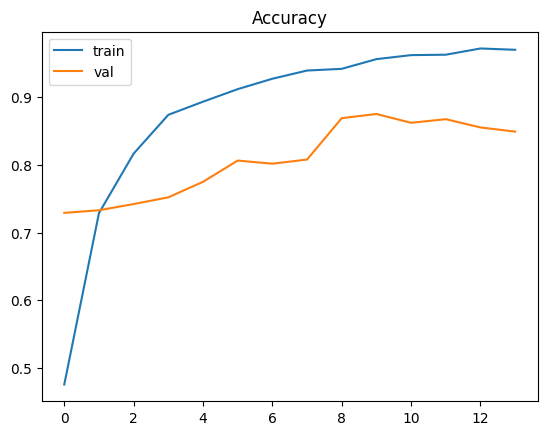

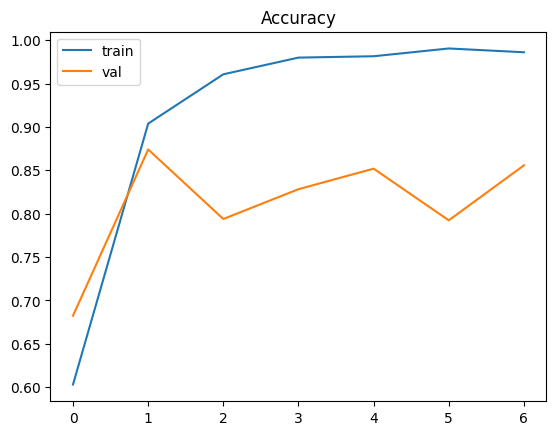

In [ ]:
def plot_history(history):

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.legend(['train','val'])
    plt.title("Accuracy")
    plt.show()

plot_history(history_mlp)
plot_history(history_lstm)